# Single-image COMFORT MCQ Analysis

This notebook automatically loads all `mcq_{length}_{model}.csv` files in this folder, prepares consistent prediction labels, and visualizes the full test matrix.

Expected complete single-image runs have 144 rows: 9 objects x 4 relations x 4 camera views.

In [1]:
import os
import re
import glob
import sys
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv.field_size_limit(sys.maxsize)

BASE_DIR = "."
LENGTHS = ["short", "middle", "long"]
RELATIONS = ["front", "behind", "left", "right"]
OBJECT_POSITIONS = ["left", "right", "front", "behind"]
MODEL_ORDER = [
    "internvl",
    "internvl_thinking",
    "qwen3vl",
    "qwen3vl_thinking",
    "qwen3_5vl",
    "qwen3_5vl_thinking",
    "gemma4",
    "gemma4_thinking",
]
RELATION_MAP = {
    "infrontof": "front",
    "totheleft": "left",
    "totheright": "right",
    "behind": "behind",
}
TRUE_LABEL_GROUPS = {
    "front_behind": ["front", "behind"],
    "left_right": ["left", "right"],
}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)

EXAMPLE_IMAGES = {
    "left": "/home/zzou/COMFORT/data/comfort_human_car/totheleft/bicycle__totheleft__cam_back/0.png",
    "right": "/home/zzou/COMFORT/data/comfort_human_car/totheright/bicycle__totheright__cam_back/0.png",
    "front": "/home/zzou/COMFORT/data/comfort_human_car/behind/bicycle__behind__cam_back/0.png",
    "behind": "/home/zzou/COMFORT/data/comfort_human_car/infrontof/bicycle__infrontof__cam_back/0.png",
}


def ordered_models(models):
    known = [m for m in MODEL_ORDER if m in models]
    extra = sorted(m for m in models if m not in MODEL_ORDER)
    return known + extra


def parse_result_filename(path, prefix="mcq"):
    name = os.path.basename(path)
    pattern = rf"^{prefix}_(short|middle|long)_(.+)\.csv$"
    m = re.match(pattern, name)
    if not m:
        return None
    return m.group(2), m.group(1)


def discover_result_files(prefix="mcq"):
    found = {}
    for path in sorted(glob.glob(os.path.join(BASE_DIR, f"{prefix}_*.csv"))):
        parsed = parse_result_filename(path, prefix=prefix)
        if parsed is None:
            continue
        model, length = parsed
        found[(model, length)] = path
    return found


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:
            mapping[letter] = "front"
        elif "behind" in text:
            mapping[letter] = "behind"
        elif "left" in text:
            mapping[letter] = "left"
        elif "right" in text:
            mapping[letter] = "right"
    return mapping


def extract_comfort_path_info(image_path):
    image_path = str(image_path)
    parts = os.path.dirname(image_path).split("/")
    raw_relation = parts[-2]
    folder_name = parts[-1]
    segments = folder_name.split("__")
    obj = segments[0] if segments else None
    cam_segment = segments[-1] if segments else ""
    camera_position = cam_segment.split("_")[-1]

    camera_perspective = None
    if (raw_relation == "behind" and camera_position == "left") or (raw_relation == "infrontof" and camera_position == "right") or (raw_relation == "totheleft" and camera_position == "front") or (raw_relation == "totheright" and camera_position == "back"):
        camera_perspective = "right"
    elif (raw_relation == "behind" and camera_position == "right") or (raw_relation == "infrontof" and camera_position == "left") or (raw_relation == "totheleft" and camera_position == "back") or (raw_relation == "totheright" and camera_position == "front"):
        camera_perspective = "left"
    elif (raw_relation == "behind" and camera_position == "front") or (raw_relation == "infrontof" and camera_position == "back") or (raw_relation == "totheleft" and camera_position == "right") or (raw_relation == "totheright" and camera_position == "left"):
        camera_perspective = "behind"
    elif (raw_relation == "behind" and camera_position == "back") or (raw_relation == "infrontof" and camera_position == "front") or (raw_relation == "totheleft" and camera_position == "left") or (raw_relation == "totheright" and camera_position == "right"):
        camera_perspective = "front"

    return {
        "raw_relation": raw_relation,
        "object": obj,
        "cam_view": f"cam_{camera_position}",
        "cam_short": camera_position,
        "object_position_under_camera_perspective": camera_perspective,
    }


def load_and_prepare(csv_path):
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        return df

    letter_maps = df["mcq_prompt"].apply(extract_letter_to_relation)
    df["pred_letter_clean"] = df["pred_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["correct_letter_clean"] = df["correct_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["opposite_letter_clean"] = df["opposite_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["pred_relation"] = [m.get(l, None) for m, l in zip(letter_maps, df["pred_letter_clean"])]
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower().replace(RELATION_MAP)
    df["opposite_relation"] = df["opposite_relation"].astype(str).str.strip().str.lower().replace(RELATION_MAP)
    df["is_correct"] = df["pred_letter_clean"] == df["correct_letter_clean"]
    df["is_opposite"] = df["pred_letter_clean"] == df["opposite_letter_clean"]
    df["has_valid_pred"] = df["pred_relation"].isin(RELATIONS)

    info = df["image_path"].apply(extract_comfort_path_info).apply(pd.Series)
    df = pd.concat([df, info], axis=1)
    df["object_position"] = df["raw_relation"].replace(RELATION_MAP)
    return df


def summarize_df(df, model, length, csv_path):
    if len(df) == 0:
        return {
            "model": model, "length": length, "rows": 0, "accuracy": np.nan,
            "opposite_rate": np.nan, "valid_pred_rate": np.nan, "csv": os.path.basename(csv_path),
            "complete_144": False,
        }
    return {
        "model": model,
        "length": length,
        "rows": len(df),
        "accuracy": df["is_correct"].mean(),
        "opposite_rate": df["is_opposite"].mean(),
        "valid_pred_rate": df["has_valid_pred"].mean(),
        "csv": os.path.basename(csv_path),
        "complete_144": len(df) == 144,
    }


def relation_breakdown(df, model, length):
    rows = []
    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        rows.append({
            "model": model,
            "length": length,
            "relation": rel,
            "n": len(sub),
            "accuracy": sub["is_correct"].mean() if len(sub) else np.nan,
            "opposite_rate": sub["is_opposite"].mean() if len(sub) else np.nan,
        })
    return rows


def plot_confusion_on_ax(df, ax, title, true_labels=RELATIONS):
    plot_df = df[df["correct_relation"].isin(true_labels) & df["pred_relation"].isin(RELATIONS)].copy()
    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return
    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index",
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)
    sns.heatmap(cm_df, ax=ax, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")

print("Helpers loaded.")

Helpers loaded.


## 1. Load All Single-image CSVs

The loader discovers files matching `mcq_{short,middle,long}_{model}.csv`, skips empty files, and records whether each run is complete (`rows == 144`).

In [2]:
files = discover_result_files(prefix="mcq")
all_dfs = defaultdict(dict)
summary_rows = []
relation_rows = []

for model in ordered_models({m for m, _ in files}):
    for length in LENGTHS:
        path = files.get((model, length))
        if path is None:
            continue
        df = load_and_prepare(path)
        if len(df) == 0:
            print(f"Skip empty file: {os.path.basename(path)}")
            continue
        all_dfs[model][length] = df
        summary_rows.append(summarize_df(df, model, length, path))
        relation_rows.extend(relation_breakdown(df, model, length))

summary_df = pd.DataFrame(summary_rows)
relation_df = pd.DataFrame(relation_rows)
models = ordered_models(all_dfs.keys())

print(f"Loaded {len(summary_df)} non-empty single-image result files.")
display(summary_df.sort_values(["model", "length"]).reset_index(drop=True))

missing = []
for model in MODEL_ORDER:
    for length in LENGTHS:
        if (model, length) not in files:
            missing.append({"model": model, "length": length, "expected_csv": f"mcq_{length}_{model}.csv"})
missing_df = pd.DataFrame(missing)
print("Missing expected files:")
display(missing_df if len(missing_df) else pd.DataFrame([{"status": "none"}]))

Skip empty file: mcq_short_gemma3.csv
Loaded 13 non-empty single-image result files.


,model,length,rows,accuracy,opposite_rate,valid_pred_rate,csv,complete_144
0,gemma4,long,144,0.250000,0.263889,0.979167,mcq_long_gemma4.csv,True
1,gemma4,middle,144,0.256944,0.277778,1.000000,mcq_middle_gemma4.csv,True
2,gemma4,short,144,0.270833,0.284722,1.000000,mcq_short_gemma4.csv,True
3,gemma4_thinking,short,106,0.169811,0.235849,1.000000,mcq_short_gemma4_thinking.csv,False
4,internvl,long,144,0.298611,0.277778,1.000000,mcq_long_internvl.csv,True
5,internvl,middle,144,0.284722,0.305556,1.000000,mcq_middle_internvl.csv,True
6,internvl,short,144,0.284722,0.305556,1.000000,mcq_short_internvl.csv,True
7,qwen3_5vl_thinking,long,144,0.604167,0.062500,1.000000,mcq_long_qwen3_5vl_thinking.csv,True
8,qwen3_5vl_thinking,middle,144,0.361111,0.236111,1.000000,mcq_middle_qwen3_5vl_thinking.csv,True
9,qwen3_5vl_thinking,short,46,0.565217,0.152174,1.000000,mcq_short_qwen3_5vl_thinking.csv,False


Missing expected files:


,model,length,expected_csv
0,internvl_thinking,short,mcq_short_internvl_thinking.csv
1,internvl_thinking,middle,mcq_middle_internvl_thinking.csv
2,internvl_thinking,long,mcq_long_internvl_thinking.csv
3,qwen3vl_thinking,short,mcq_short_qwen3vl_thinking.csv
4,qwen3vl_thinking,middle,mcq_middle_qwen3vl_thinking.csv
5,qwen3vl_thinking,long,mcq_long_qwen3vl_thinking.csv
6,qwen3_5vl,short,mcq_short_qwen3_5vl.csv
7,qwen3_5vl,middle,mcq_middle_qwen3_5vl.csv
8,qwen3_5vl,long,mcq_long_qwen3_5vl.csv
9,gemma4_thinking,middle,mcq_middle_gemma4_thinking.csv


## 2. Overall Accuracy Overview

length,short,middle,long
model,,,
internvl,0.285,0.285,0.299
qwen3vl,0.326,0.285,0.347
qwen3_5vl_thinking,0.565,0.361,0.604
gemma4,0.271,0.257,0.250
gemma4_thinking,0.170,NaN,NaN


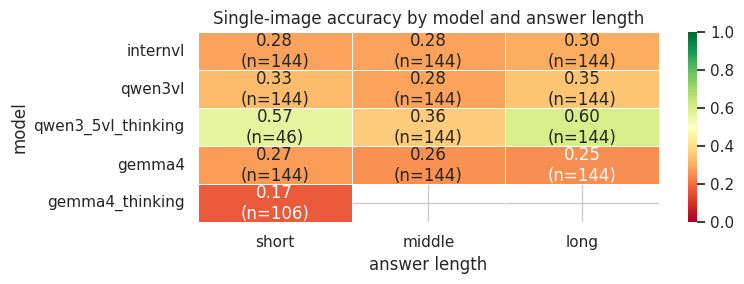

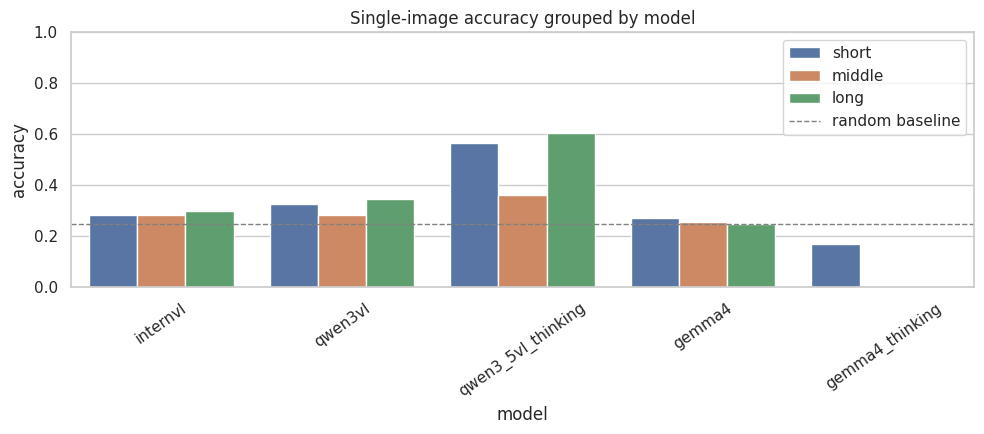

In [3]:
if len(summary_df):
    acc_pivot = summary_df.pivot(index="model", columns="length", values="accuracy").reindex(index=models, columns=LENGTHS)
    n_pivot = summary_df.pivot(index="model", columns="length", values="rows").reindex(index=models, columns=LENGTHS)

    display(acc_pivot.round(3))

    annot = acc_pivot.copy().astype(object)
    for model in acc_pivot.index:
        for length in acc_pivot.columns:
            acc = acc_pivot.loc[model, length]
            n = n_pivot.loc[model, length]
            annot.loc[model, length] = "" if pd.isna(acc) else f"{acc:.2f}\n(n={int(n)})"

    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(models))))
    sns.heatmap(acc_pivot, annot=annot, fmt="", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title("Single-image accuracy by model and answer length")
    ax.set_xlabel("answer length")
    ax.set_ylabel("model")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    plot_df = summary_df.copy()
    sns.barplot(data=plot_df, x="model", y="accuracy", hue="length", hue_order=LENGTHS, order=models, ax=ax)
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_ylim(0, 1)
    ax.set_title("Single-image accuracy grouped by model")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## 3. Accuracy and Opposite Error by True Relation

,model,length,relation,n,accuracy,opposite_rate
0,gemma4,long,behind,36,0.167,0.139
1,gemma4,long,front,36,0.278,0.333
2,gemma4,long,left,36,0.250,0.278
3,gemma4,long,right,36,0.306,0.306
4,gemma4,middle,behind,36,0.111,0.222
5,gemma4,middle,front,36,0.222,0.250
6,gemma4,middle,left,36,0.306,0.333
7,gemma4,middle,right,36,0.389,0.306
8,gemma4,short,behind,36,0.194,0.167
9,gemma4,short,front,36,0.222,0.194


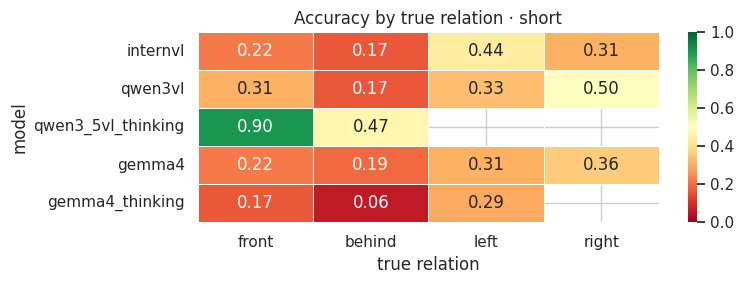

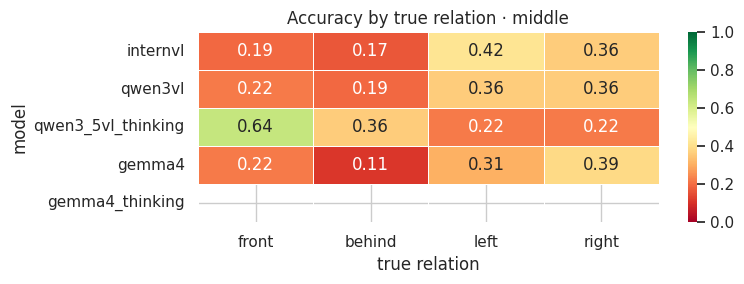

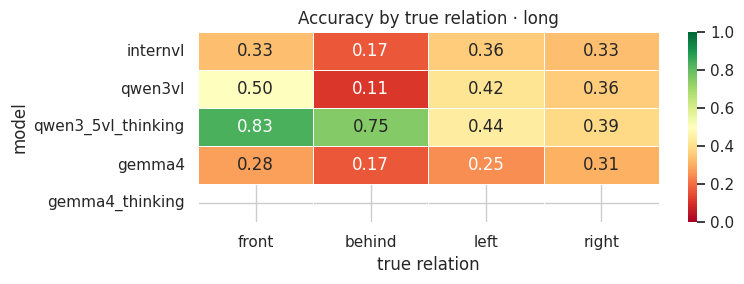

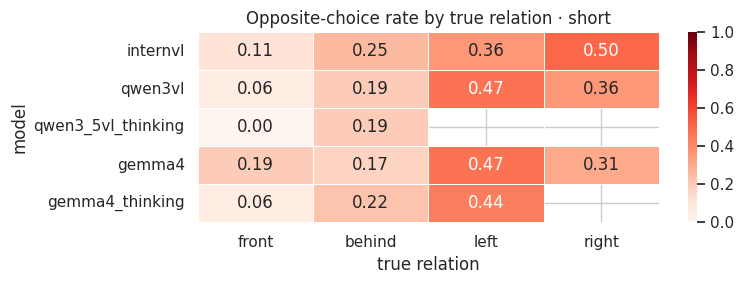

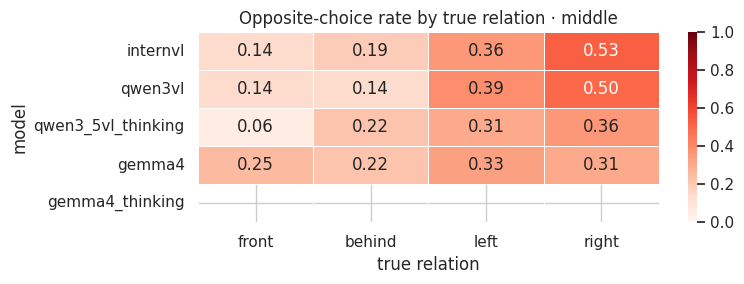

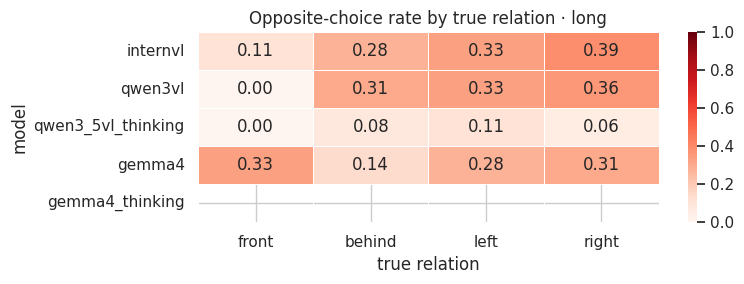

In [4]:
if len(relation_df):
    display(relation_df.sort_values(["model", "length", "relation"]).round(3).reset_index(drop=True))

    for metric, title, cmap in [
        ("accuracy", "Accuracy by true relation", "RdYlGn"),
        ("opposite_rate", "Opposite-choice rate by true relation", "Reds"),
    ]:
        for length in LENGTHS:
            sub = relation_df[relation_df["length"] == length]
            if len(sub) == 0:
                continue
            pivot = sub.pivot(index="model", columns="relation", values=metric).reindex(index=models, columns=RELATIONS)
            fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(models))))
            sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1, linewidths=0.5, ax=ax)
            ax.set_title(f"{title} · {length}")
            ax.set_xlabel("true relation")
            ax.set_ylabel("model")
            plt.tight_layout()
            plt.show()

## 4. Confusion Matrices

Each model is shown as short/middle/long confusion matrices. Rows are true labels; columns are predicted labels.

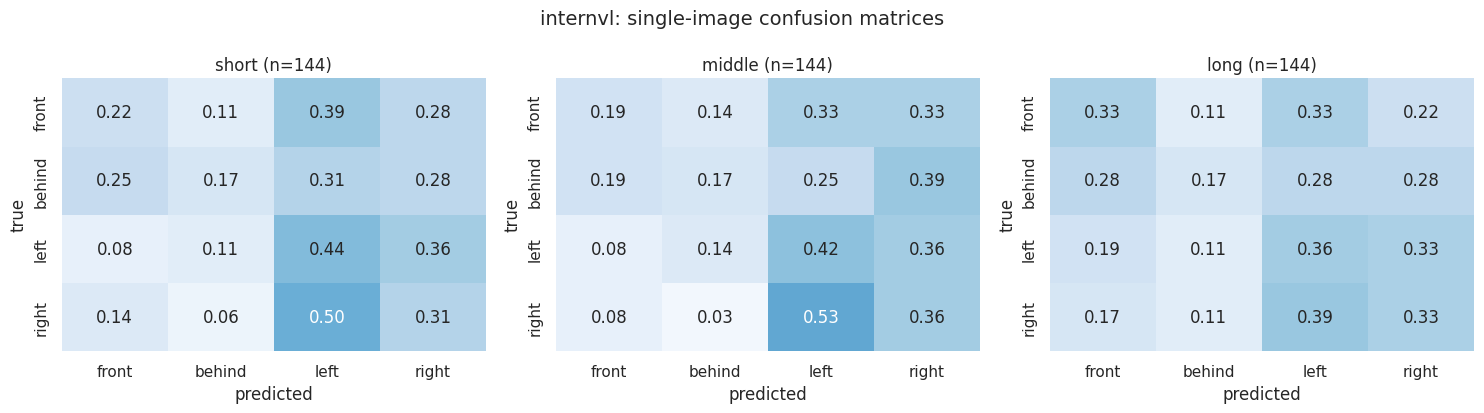

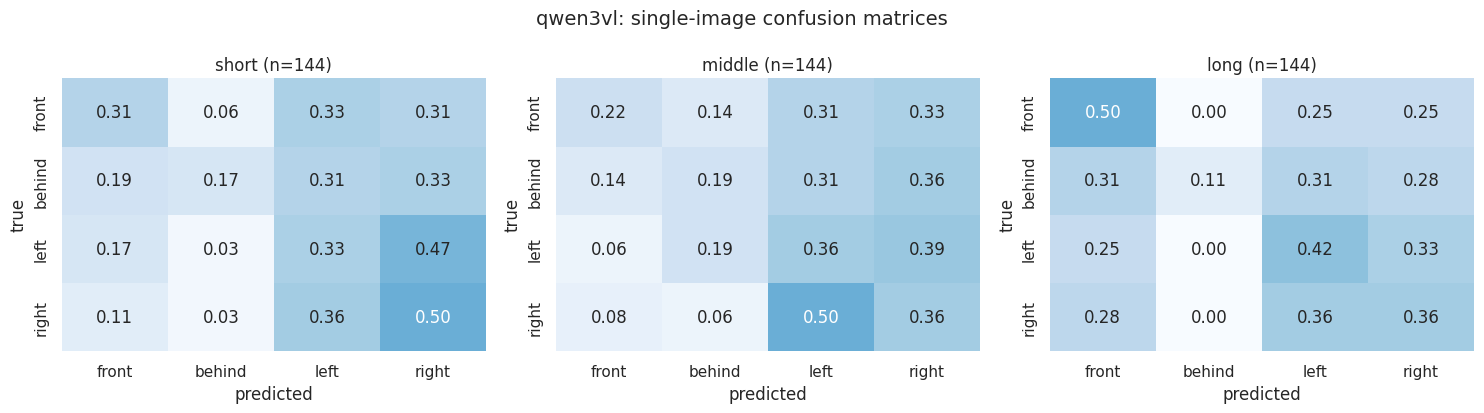

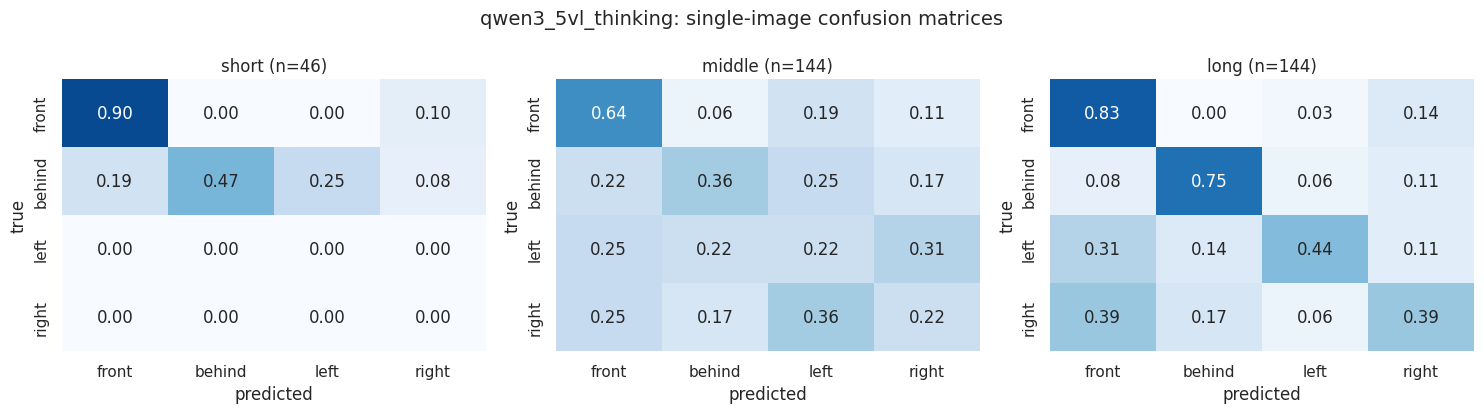

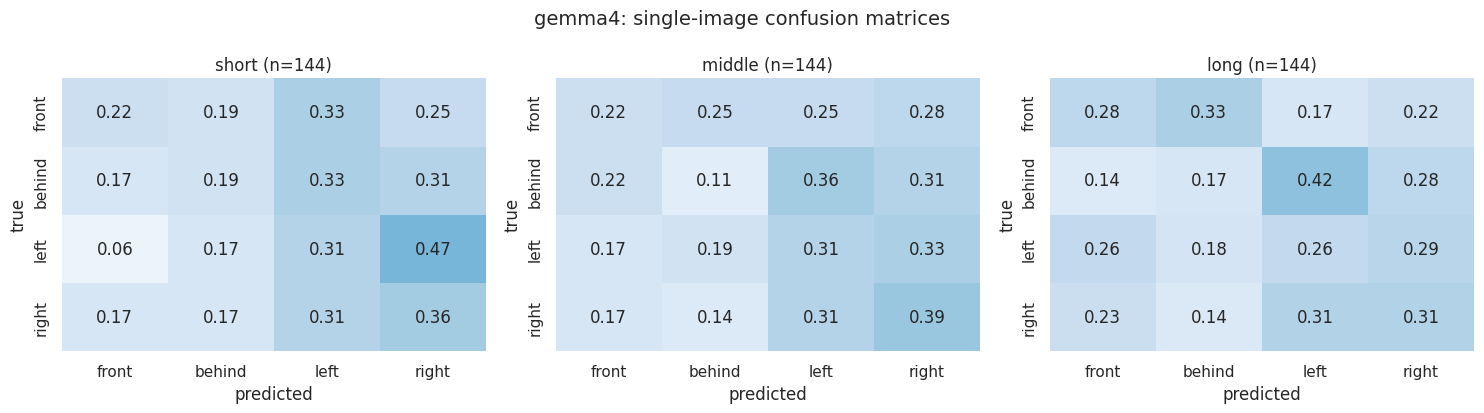

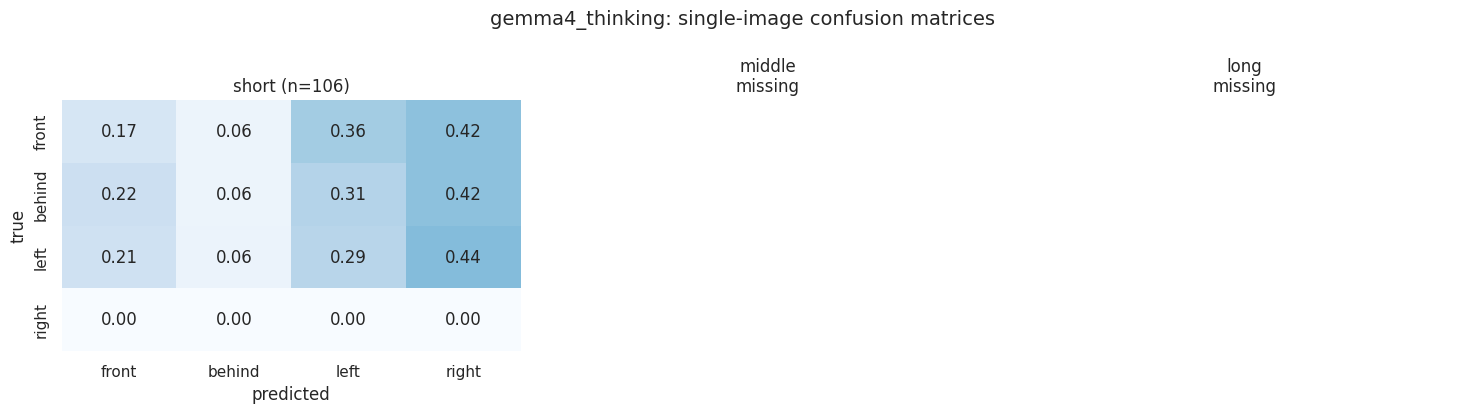

In [5]:
for model in models:
    available = [l for l in LENGTHS if l in all_dfs.get(model, {})]
    if not available:
        continue
    fig, axes = plt.subplots(1, len(LENGTHS), figsize=(5 * len(LENGTHS), 4.2))
    if len(LENGTHS) == 1:
        axes = [axes]
    for ax, length in zip(axes, LENGTHS):
        if length not in all_dfs[model]:
            ax.axis("off")
            ax.set_title(f"{length}\nmissing")
            continue
        df = all_dfs[model][length]
        plot_confusion_on_ax(df, ax, title=f"{length} (n={len(df)})", true_labels=RELATIONS)
    fig.suptitle(f"{model}: single-image confusion matrices", fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Camera-perspective Bias

This reproduces the original notebook idea: group rows by how the object appears under the camera perspective, then plot relation confusion. This helps reveal whether a model follows the visible camera view instead of the person-centric relation.

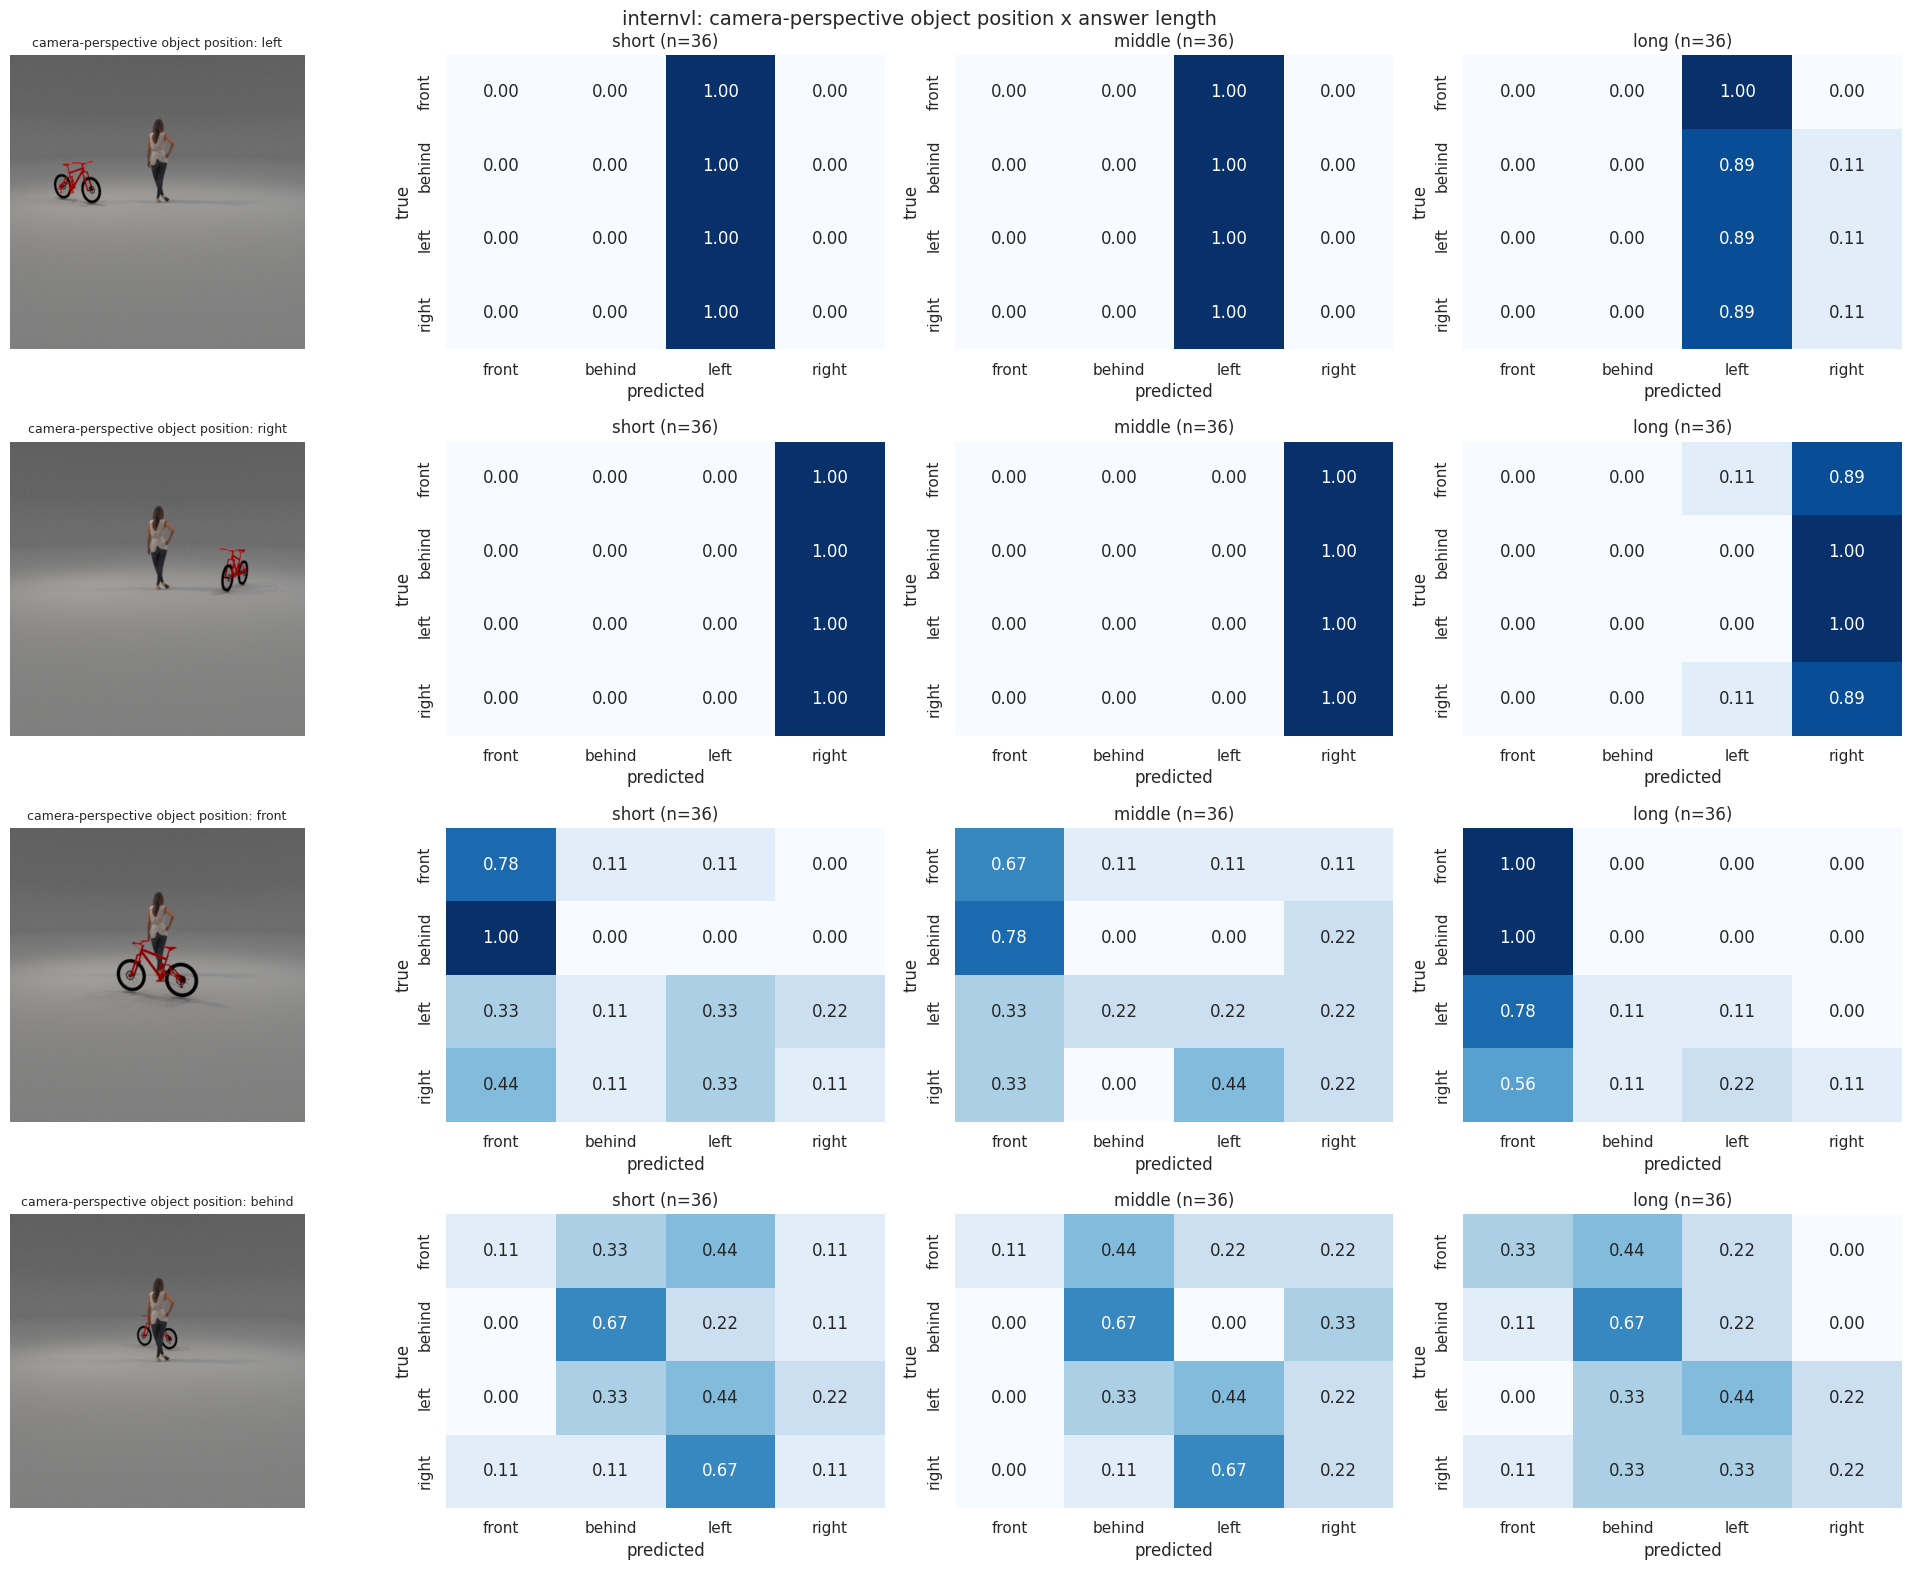

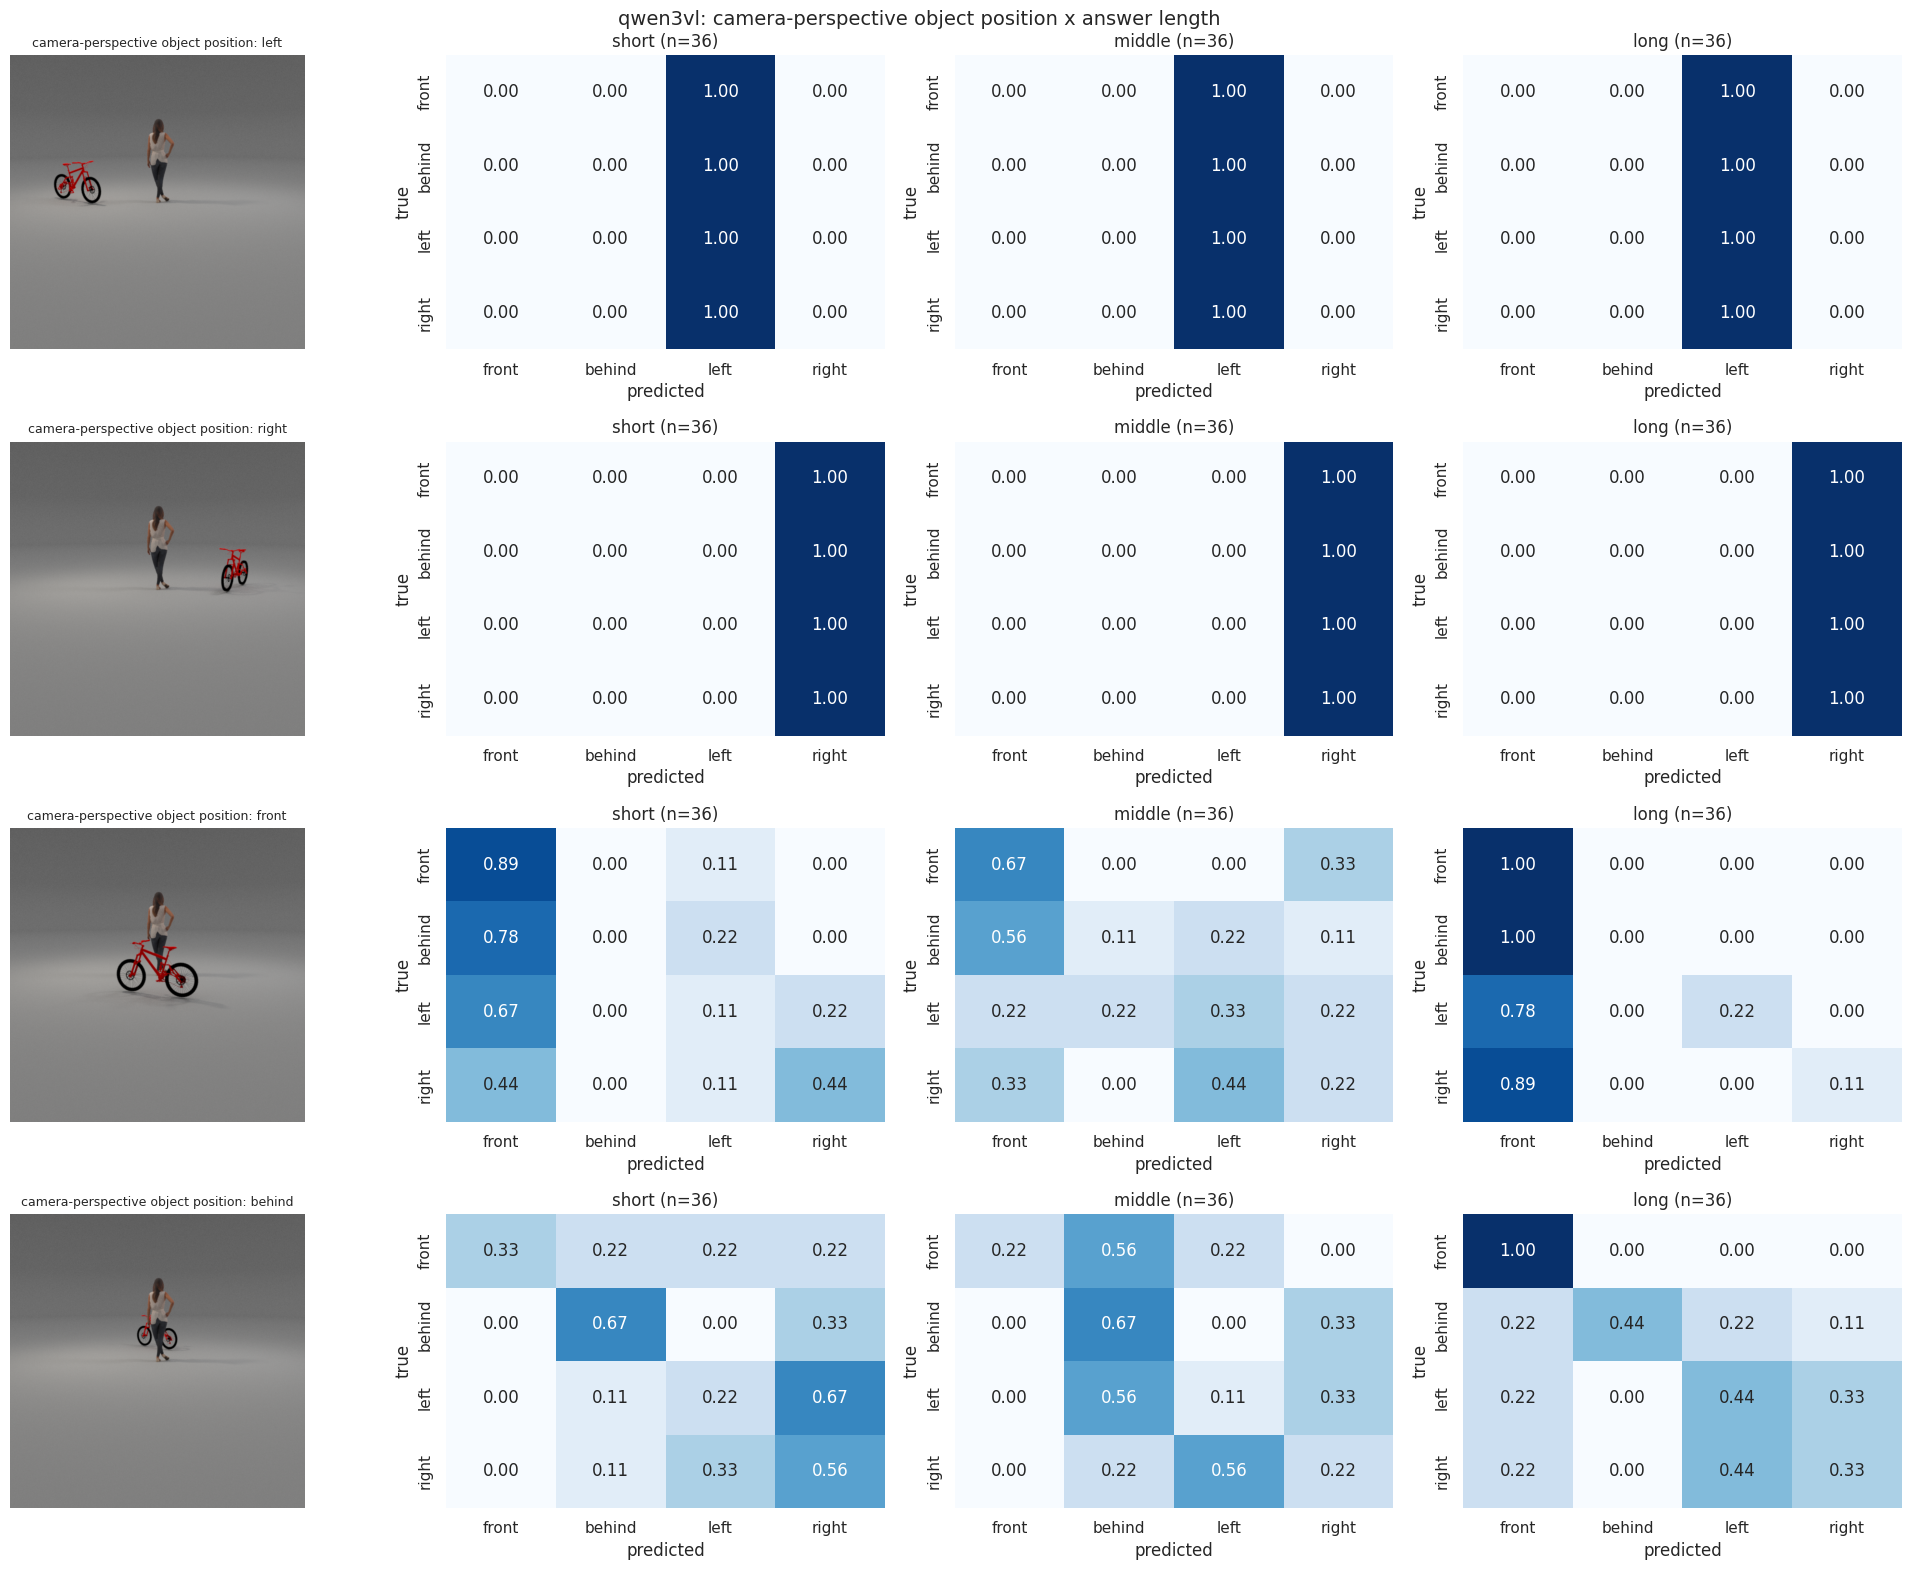

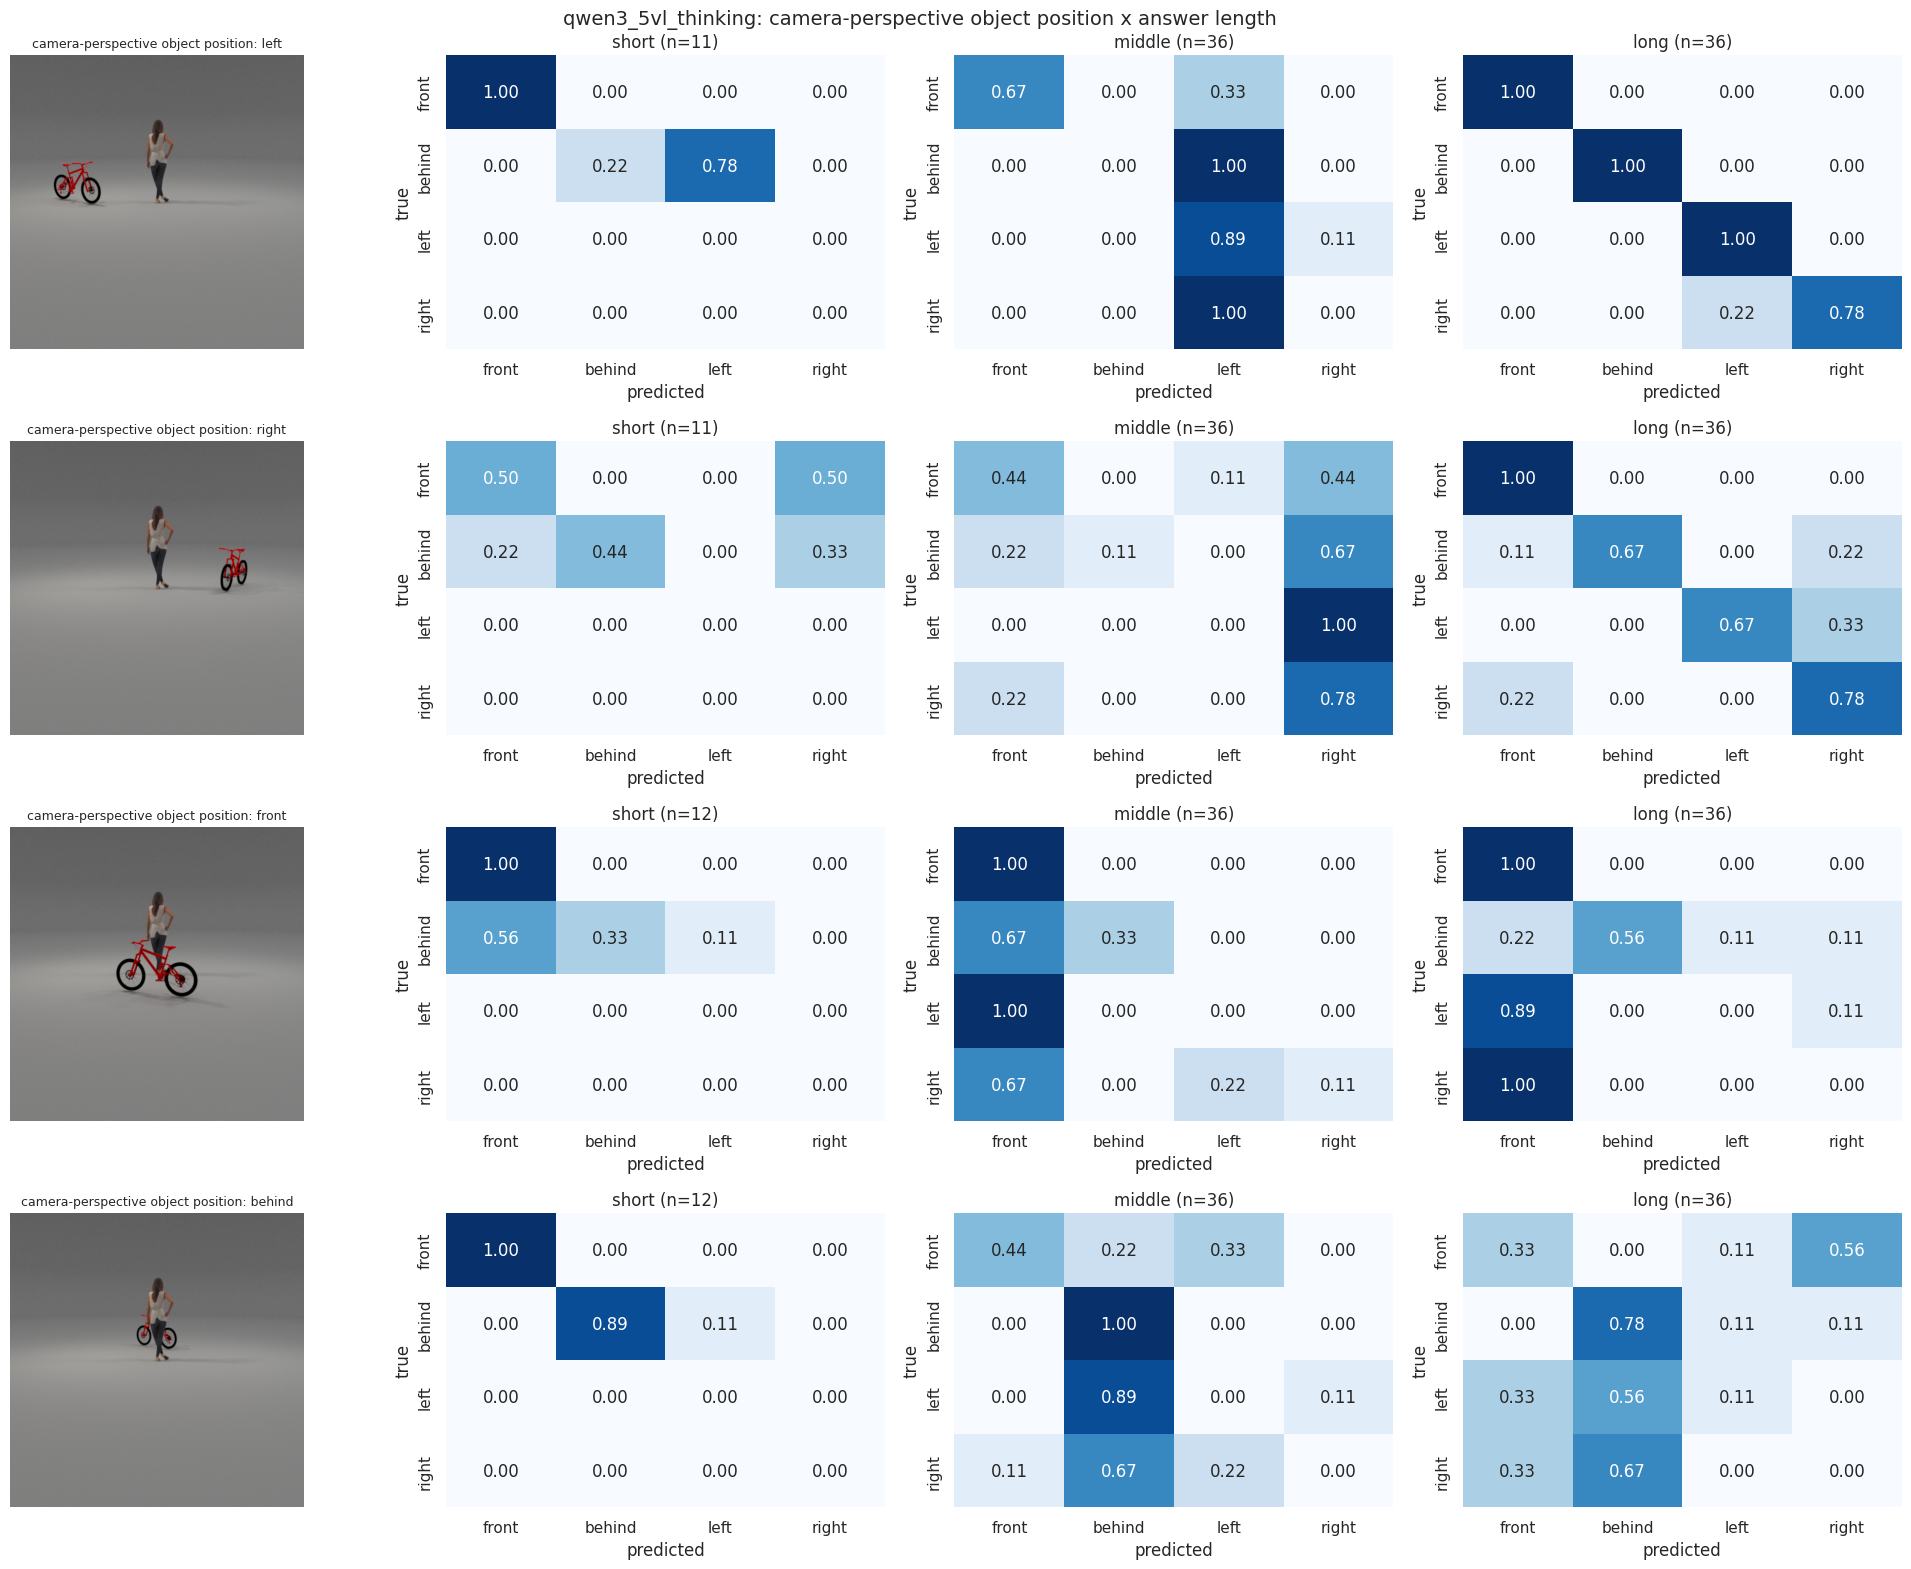

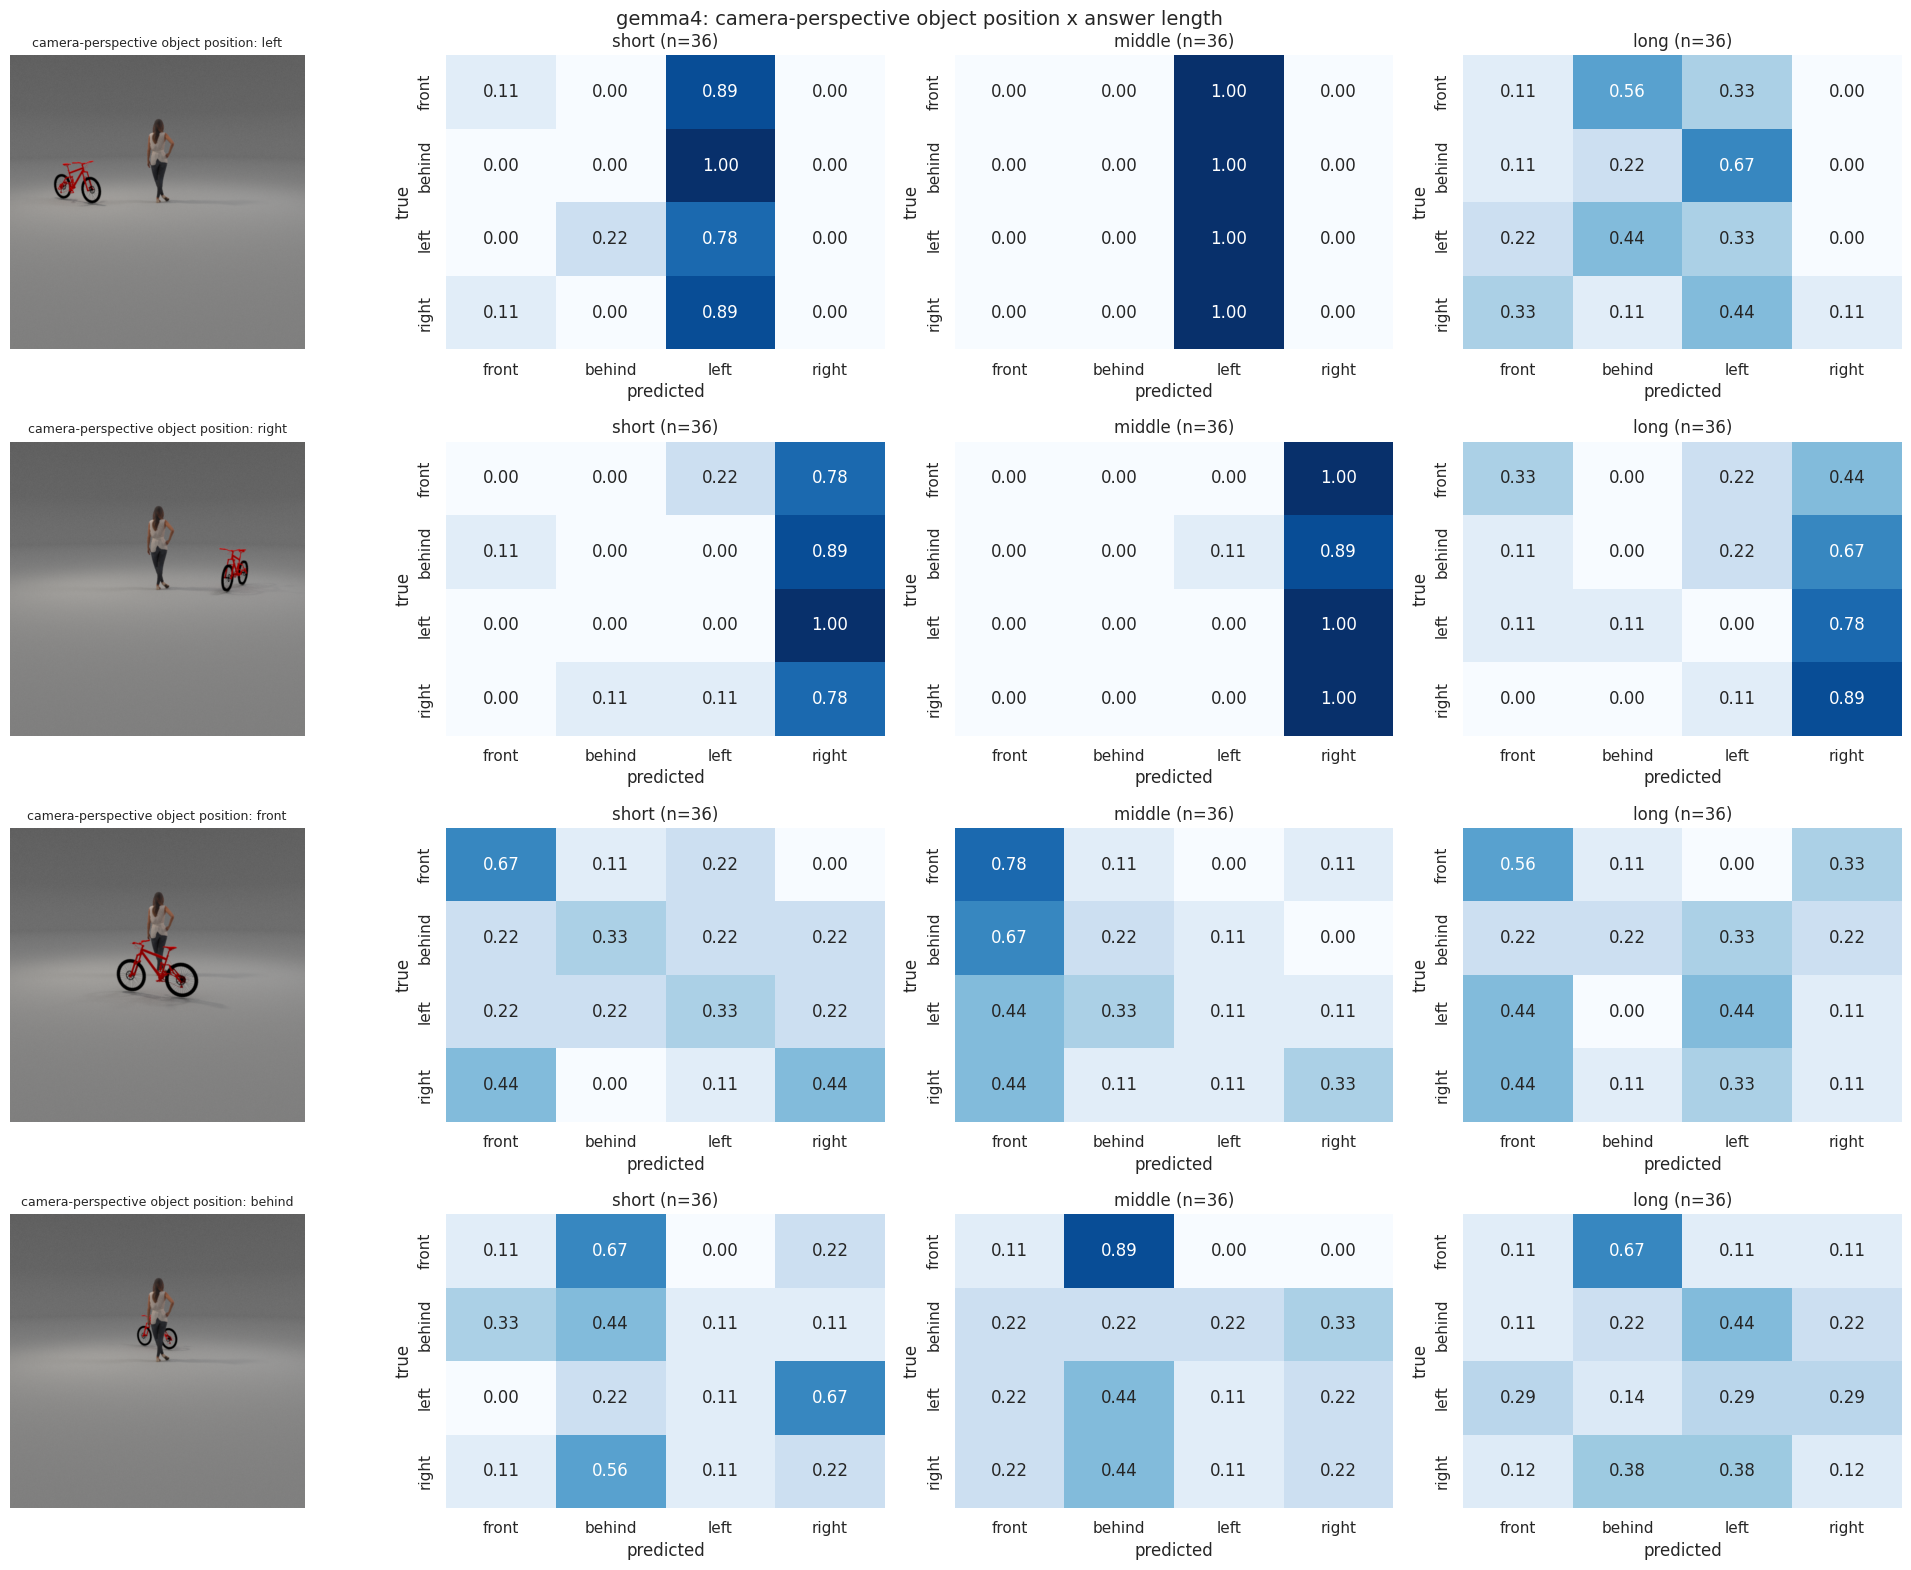

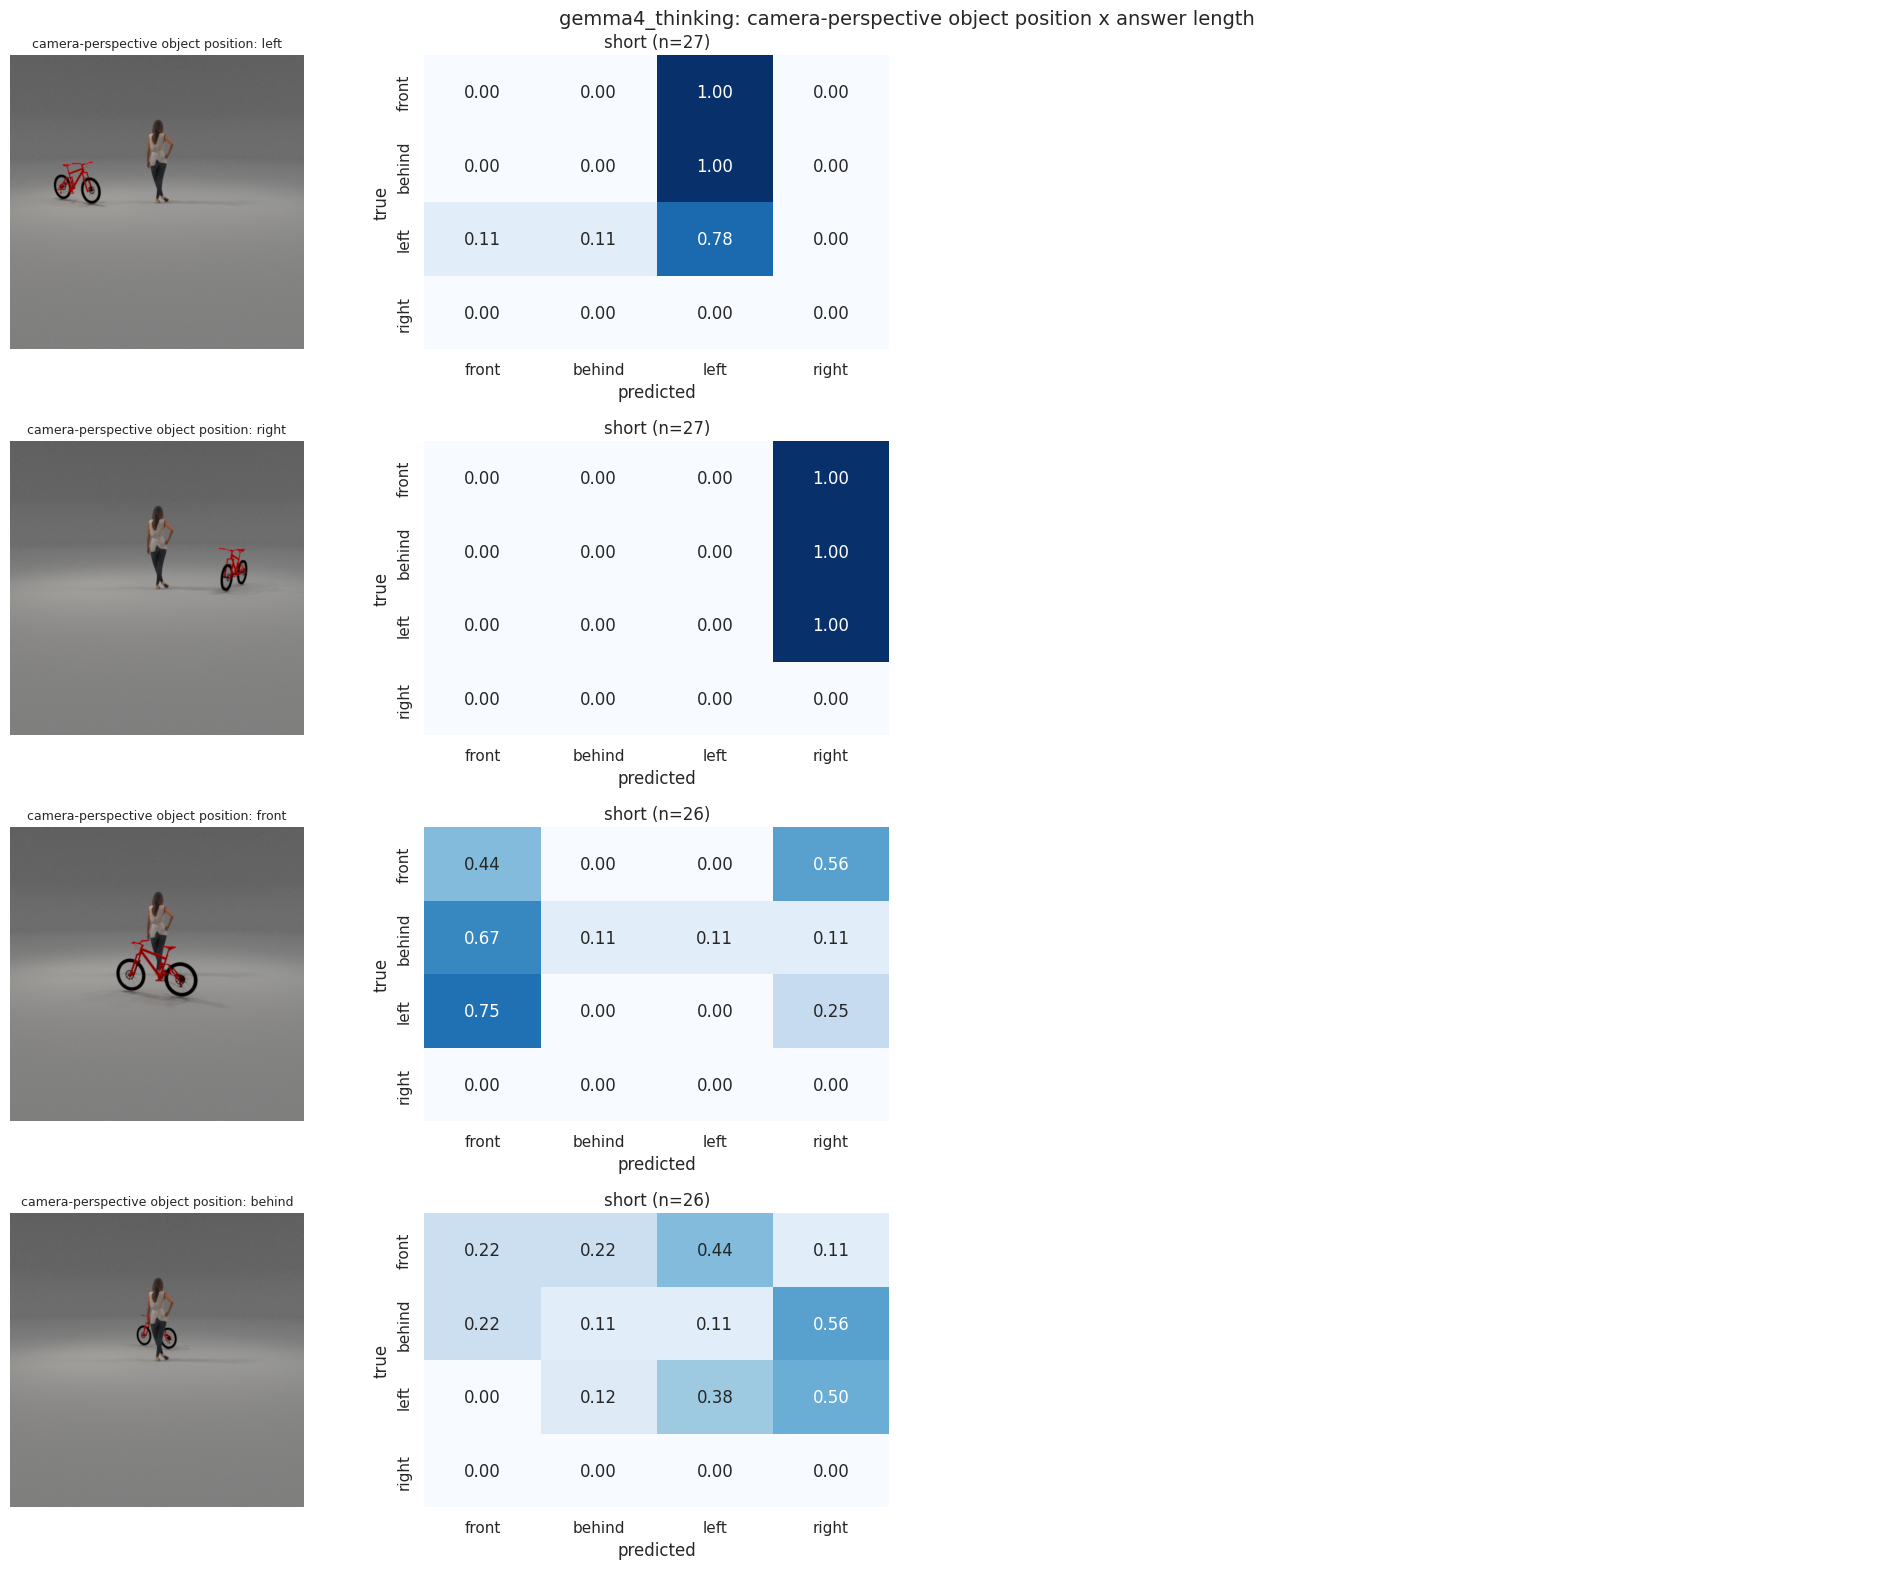

In [6]:
for model in models:
    if model not in all_dfs:
        continue
    fig, axes = plt.subplots(len(OBJECT_POSITIONS), 1 + len(LENGTHS), figsize=(20, 16))
    for j, obj_pos in enumerate(OBJECT_POSITIONS):
        img_path = EXAMPLE_IMAGES.get(obj_pos)
        if img_path and os.path.exists(img_path):
            axes[j][0].imshow(plt.imread(img_path))
        axes[j][0].axis("off")
        axes[j][0].set_title(f"camera-perspective object position: {obj_pos}", fontsize=9)
        for i, length in enumerate(LENGTHS):
            ax = axes[j][i + 1]
            if length not in all_dfs[model]:
                ax.axis("off")
                continue
            df = all_dfs[model][length]
            sub = df[df["object_position_under_camera_perspective"] == obj_pos]
            plot_confusion_on_ax(sub, ax, title=f"{length} (n={len(sub)})", true_labels=RELATIONS)
    fig.suptitle(f"{model}: camera-perspective object position x answer length", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Accuracy by Object

,model,length,object,n,accuracy
0,gemma4,long,basketball,16,0.312
1,gemma4,long,bench,16,0.312
2,gemma4,long,bicycle,16,0.250
3,gemma4,long,car,16,0.250
4,gemma4,long,chair,16,0.312
5,gemma4,long,dog,16,0.188
6,gemma4,long,duck,16,0.250
7,gemma4,long,laptop,16,0.188
8,gemma4,long,sofa,16,0.188
9,gemma4,middle,basketball,16,0.250


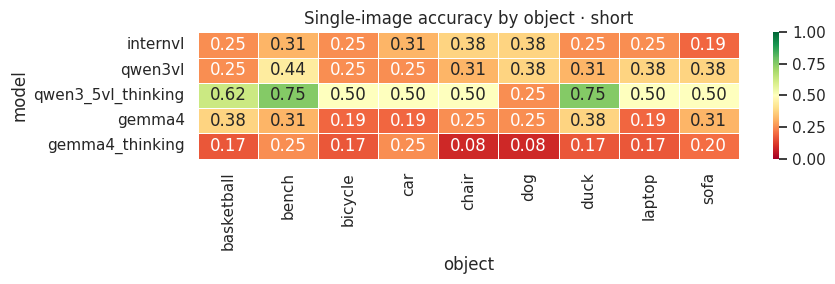

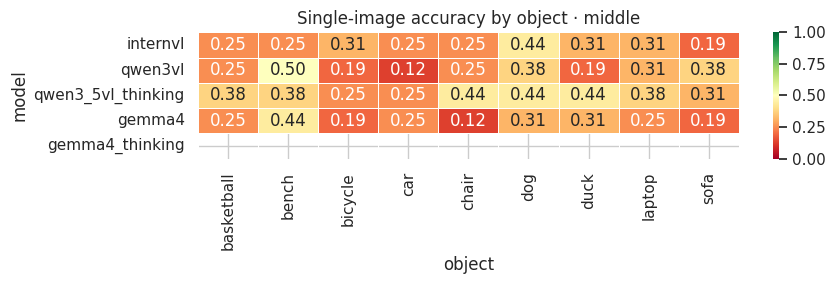

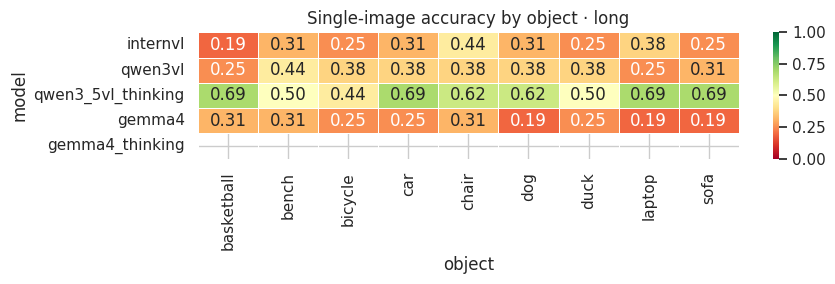

In [7]:
object_rows = []
for model, by_length in all_dfs.items():
    for length, df in by_length.items():
        for obj, sub in df.groupby("second_object"):
            object_rows.append({
                "model": model,
                "length": length,
                "object": obj,
                "n": len(sub),
                "accuracy": sub["is_correct"].mean(),
            })
object_df = pd.DataFrame(object_rows)
if len(object_df):
    display(object_df.sort_values(["model", "length", "object"]).round(3).reset_index(drop=True))
    for length in LENGTHS:
        sub = object_df[object_df["length"] == length]
        if len(sub) == 0:
            continue
        objects = sorted(sub["object"].dropna().unique())
        pivot = sub.pivot(index="model", columns="object", values="accuracy").reindex(index=models, columns=objects)
        fig, ax = plt.subplots(figsize=(max(9, 0.7 * len(objects)), max(3, 0.45 * len(models))))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax)
        ax.set_title(f"Single-image accuracy by object · {length}")
        ax.set_xlabel("object")
        ax.set_ylabel("model")
        plt.tight_layout()
        plt.show()